In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')


ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.physics import SurvivalProbablity


plt.rcParams['text.usetex']=True
plt.style.use('classic')

/Users/ipm/Documents/GitHub/NuMatterSurrogate /Users/ipm/Documents/GitHub/NuMatterSurrogate/external/PEANUTS
Warning!: Python module pyslha not found, disabling slha reading routines


In [2]:
def denormalize_delta(delta_norm, normalization_file):
    """
    Convert normalized Delta in (0, 1) back to physical Delta.

    Parameters
    ----------
    delta_norm : np.ndarray
        Shape (..., 3), model prediction.

    normalization_file : path
        delta_normalization.npz

    Returns
    -------
    Delta : np.ndarray
        Physical Delta, same shape as delta_norm.
    """

    norm = np.load(normalization_file)

    mean = norm["mean"]
    std = norm["std"]
    
    # Undo standardization
    Delta = delta_norm * std + mean

    return Delta

In [137]:
data = np.load(ROOT / 'Data' / "parameter_samples.npz")


eta = data["eta"]
energy = data["energy"]

print("Loaded:")
print("eta     :", eta.shape)
print("energy  :", energy.shape)



Loaded:
eta     : (192,)
energy  : (192,)


In [152]:
pred = np.load(ROOT /'notebooks' / "pred.npy")
param = np.load(ROOT /'notebooks' / "param.npy")

print(list(data.keys()), pred.shape, param.shape)

pred_phy = denormalize_delta(
    pred,
    ROOT / "data" / "delta_normalization.npz"
)


print(pred_phy.shape)

['param', 'eta', 'energy', 'U_Evol', 'Mass_W'] (88, 192, 192, 3) (88, 2)
(88, 192, 192, 3)


In [153]:
index = 64

U_evolved_net = pred_phy[index]

th12_norm = param[index,0]
dm21_norm = param[index,1]

theta12 = (th12_norm + 1) * (10/2) + 30.  
dm21 = (dm21_norm + 1) * (3e-5/2) + 6e-5

print("theta12 :", theta12)
print("dm21    :", dm21)

model = SurvivalProbablity()

model.th12 = np.radians(theta12)
model.DeltamSq21 = dm21


U_evolved_tes, mass_weights_tes, U_evolved_vac_tes  = model._MSW(np.radians(eta), energy)

theta12 : 35.50000011920929
dm21    : 8.099999964237214e-05


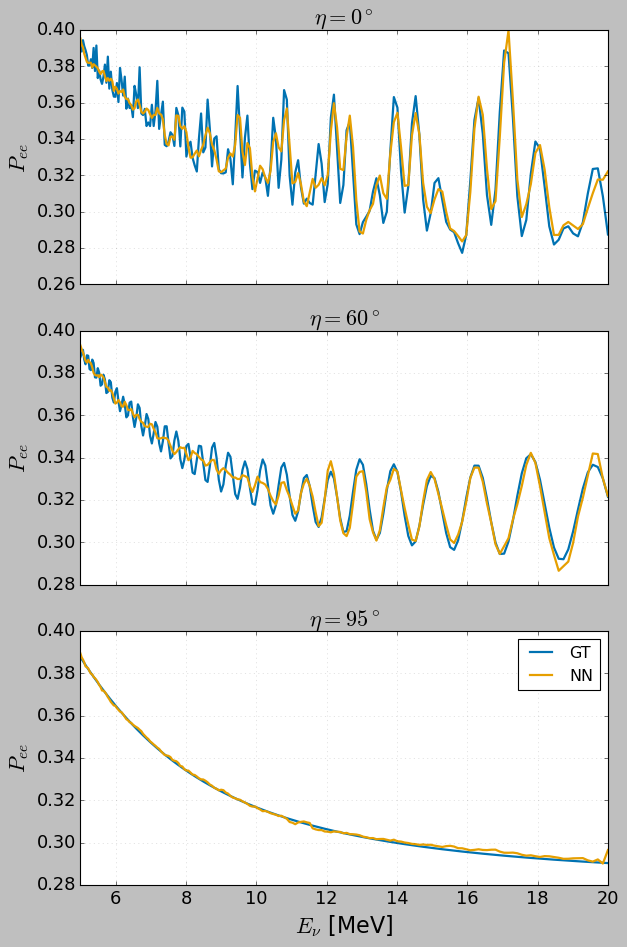

In [150]:
fig, axes = plt.subplots(3, 1, figsize=(8, 12), sharex=True)

# eta = 0
axes[0].set_xlim(5,20)
axes[0].plot(
    energy,
    np.sum(U_evolved_tes[0, :] * mass_weights_tes, axis=1),
    lw=2, color='#0072B2', ls='-'
)
axes[0].plot(
    energy,
    np.sum(U_evolved_net[0, :] * mass_weights_tes, axis=1),
    lw=2, color='#E69F00'
)
axes[0].set_title(r'$\eta = 0^\circ$', fontsize=20)

# eta = 60
axes[1].set_xlim(5,20)
axes[1].plot(
    energy,
    np.sum(U_evolved_tes[121, :] * mass_weights_tes, axis=1),
    lw=2, color='#0072B2', ls='-'
)
axes[1].plot(
    energy,
    np.sum(U_evolved_net[121, :] * mass_weights_tes, axis=1),
    lw=2, color='#E69F00'
)
axes[1].set_title(r'$\eta = 60^\circ$', fontsize=20)

# eta = 95
axes[2].set_xlim(5,20)
axes[2].plot(
    energy,
    np.sum(U_evolved_tes[-1, :] * mass_weights_tes, axis=1),
    lw=2, color='#0072B2', ls='-',label='GT'
)
axes[2].plot(
    energy,
    np.sum(U_evolved_net[-1, :] * mass_weights_tes, axis=1),
    lw=2, color='#E69F00', label='NN'
)
axes[2].set_title(r'$\eta = 95^\circ$', fontsize=20)

# Labels
for ax in axes:
    ax.set_ylabel(r'$P_{ee}$', fontsize=20)
    ax.tick_params(axis='both', labelsize=16)
    ax.grid(alpha=0.2)

axes[2].set_xlabel(r'$E_\nu$ [MeV]', fontsize=20)


plt.legend()
plt.tight_layout()
plt.savefig(
    'p_ee.pdf',
    bbox_inches='tight'
)

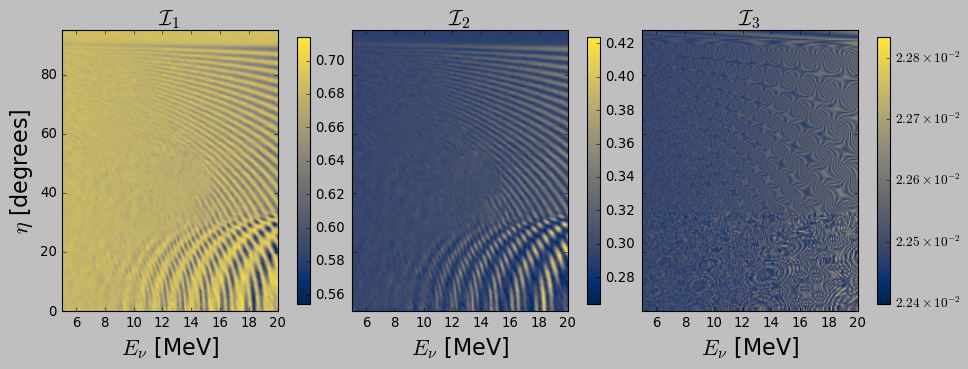

In [50]:
image1 = U_evolved_net[:, :, 0]
image2 = U_evolved_net[:, :, 1]
image3 = U_evolved_net[:, :, 2]

fig, axes = plt.subplots(
    1, 3,
    figsize=(12, 4.5),
    sharex=True,
    sharey=True,
    constrained_layout=True
)

# -------------------------------------------------
# Image 1
# -------------------------------------------------
vmin1 = image1.min().item()
vmax1 = image1.max().item()

im1 = axes[0].imshow(
    image1,
    origin='lower',
    extent=[5, 20, 0, 95],
    aspect='auto',
    vmin=vmin1,
    vmax=vmax1,
    cmap='cividis',
)

axes[0].set_xlabel(r'$E_\nu$ [MeV]', fontsize=20)
axes[0].set_ylabel(r'$\eta$ [degrees]', fontsize=20)
axes[0].set_title(r'$\mathcal{I}_1$', fontsize=20)

cbar1 = fig.colorbar(
    im1,
    ax=axes[0],
    #label=r'$\mathcal{I}_1$',
    shrink=0.95
)

# -------------------------------------------------
# Image 2
# -------------------------------------------------
vmin2 = image2.min().item()
vmax2 = image2.max().item()

im2 = axes[1].imshow(
    image2,
    origin='lower',
    extent=[5, 20, 0, 95],
    aspect='auto',
    vmin=vmin2,
    vmax=vmax2,
    cmap='cividis',
)

axes[1].set_xlabel(r'$E_\nu$ [MeV]', fontsize=20)
axes[1].set_title(r'$\mathcal{I}_2$', fontsize=20)


cbar2 = fig.colorbar(
    im2,
    ax=axes[1],
    #label=r'$\mathcal{I}_2$',
    shrink=0.95,
)

#cbar2.set_label(r'$\mathcal{I}_2$', fontsize=20)

# -------------------------------------------------
# Image 3
# -------------------------------------------------
vmin3 = image3.min().item()
vmax3 = image3.max().item()

im3 = axes[2].imshow(
    image3,
    origin='lower',
    extent=[5, 20, 0, 95],
    aspect='auto',
    vmin=vmin3,
    vmax=vmax3,
    cmap='cividis',
)

axes[2].set_xlabel(r'$E_\nu$ [MeV]', fontsize=20)
axes[2].set_title(r'$\mathcal{I}_3$', fontsize=20)
cbar3 = fig.colorbar(
    im3,
    ax=axes[2],
    #label=r'$\mathcal{I}_3$',
    shrink=0.95
)

import numpy as np
from matplotlib.ticker import FuncFormatter
# Scientific exponent based on actual values
max_abs = max(abs(vmin3), abs(vmax3))
exponent = int(np.floor(np.log10(max_abs)))

# Show complete value on every tick
formatter = FuncFormatter(
    lambda x, pos: rf'${x / 10**exponent:.2f}\times10^{{{exponent}}}$'
)

cbar3.formatter = formatter
cbar3.update_ticks()

# IMPORTANT: remove Matplotlib's "+2.2e-2" offset
cbar3.ax.yaxis.offsetText.set_visible(False)

plt.savefig(
    'I_i_pred.pdf',
    bbox_inches='tight'
)